<a href="https://colab.research.google.com/github/mikbal06/LexisNexis-1B-detecting-fraudulent-insurance-claims/blob/main/notebooks/Data_Exploration_and_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LexisNexis 1B - Fraudulent Insurance Claim Detection

### Data Exploration and Cleaning

## Setup

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import re

pd.set_option('display.max_columns', None)

In [ ]:
# Ingest data
!pip install -q gdown
import gdown

file_id = "1Er9mhMuJLK2T_pp5VpESCihybcn5ASXd"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "fraud_oracle.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1Er9mhMuJLK2T_pp5VpESCihybcn5ASXd
To: /content/fraud_oracle.csv
100%|██████████| 3.62M/3.62M [00:00<00:00, 239MB/s]


'fraud_oracle.csv'

## Data Inspection

In [ ]:
# Load in data
df = pd.read_csv('fraud_oracle.csv')
df.shape

(15420, 33)

### Inspect 'Age' column for values of 0

In [ ]:
# See how many instances have age 0
df['Age'].value_counts().sort_index().head()
(df['Age'] == 0).sum()

np.int64(320)

In [ ]:
# See what proportion of rows with age 0 have been or haven't been marked as fraud
df[df['Age'] == 0]['FraudFound_P'].value_counts(normalize=True)

,proportion
FraudFound_P,
0,0.903125
1,0.096875


In [ ]:
# See in which age group the age of 0 appears --> all 16-17
df[df['Age'] == 0]['AgeOfPolicyHolder'].value_counts()

,count
AgeOfPolicyHolder,
16 to 17,320


In [ ]:
# Replace the 0 age with 16.5 years of age
df.loc[df['Age'] == 0, 'Age'] = 16.5

/tmp/ipykernel_5900/4080826199.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '16.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Age'] == 0, 'Age'] = 16.5


In [ ]:
# Verify that age column change worked
(df['Age'] == 0).sum()

np.int64(0)

### Examine target imbalance

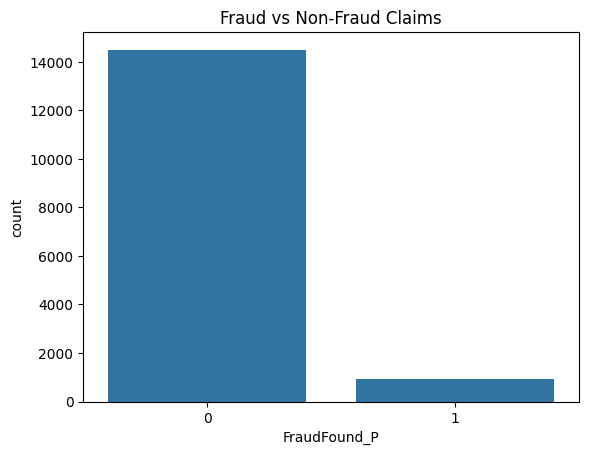

,proportion
FraudFound_P,
0,0.940143
1,0.059857


In [ ]:
sns.countplot(x='FraudFound_P', data=df)
plt.title('Fraud vs Non-Fraud Claims')
plt.show()

df['FraudFound_P'].value_counts(normalize=True)

### Inspect Vehicle Price Column

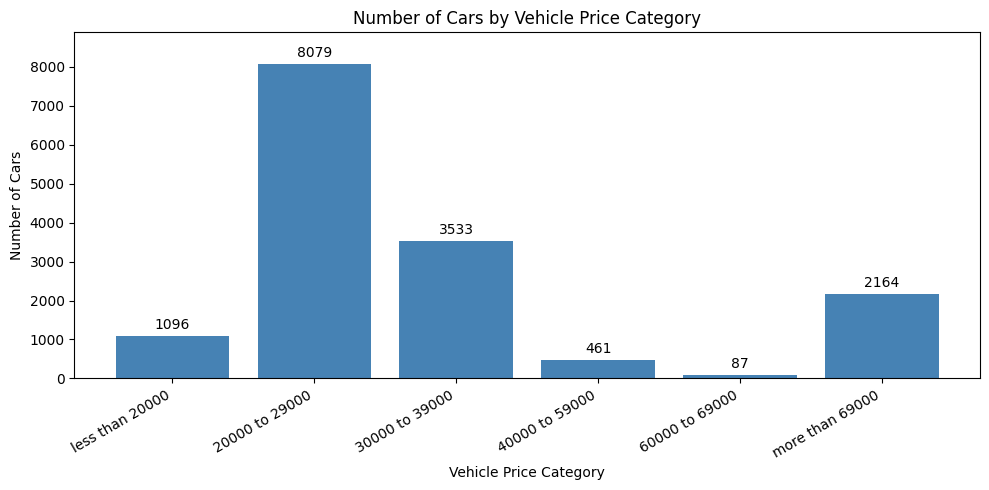

In [ ]:
# Find each unique category in the vehicle price column and counting its occurrences.

def price_sort_key(category):
    text = category.lower().replace(",", "")

    if "less than" in text:
        return float("-inf")  # Place open-ended lower ranges first

    # Extract the first number: the lower bound for other categories.
    return float(re.search(r"\d+(?:\.\d+)?", text).group())

counts = df["VehiclePrice"].value_counts()
counts = counts.reindex(sorted(counts.index, key=price_sort_key))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(counts.index, counts.values, color="steelblue")

ax.bar_label(bars, padding=3)
ax.set_title("Number of Cars by Vehicle Price Category")
ax.set_xlabel("Vehicle Price Category")
ax.set_ylabel("Number of Cars")
ax.margins(y=0.1)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Inspect Vehicle Age Column

In [ ]:
df['AgeOfVehicle'].value_counts()

,count
AgeOfVehicle,
7 years,5807
more than 7,3981
6 years,3448
5 years,1357
new,373
4 years,229
3 years,152
2 years,73


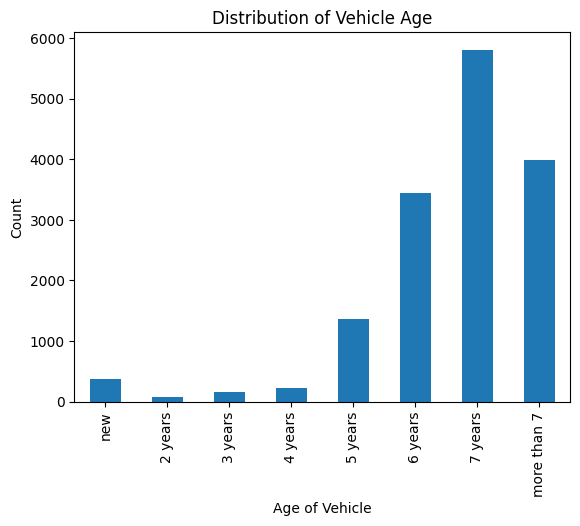

In [ ]:
# Plot vehicle age
counts = df["AgeOfVehicle"].value_counts().sort_index()
counts = counts.reindex(["new"] + [x for x in counts.index if x != "new"])

counts.plot(kind = "bar")
plt.xlabel("Age of Vehicle")
plt.ylabel("Count")
plt.title("Distribution of Vehicle Age")
plt.show()

# Past No of claims column

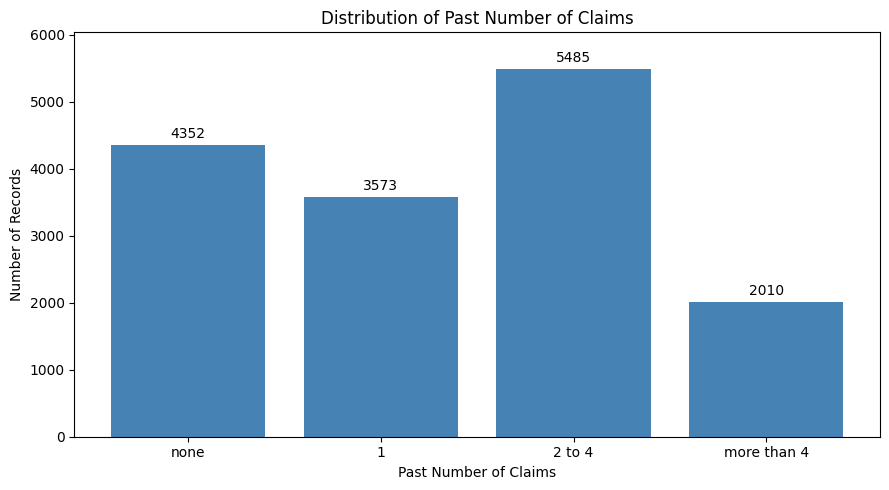

In [ ]:
counts = df["PastNumberOfClaims"].value_counts()

def claim_sort_key(category):
    if category.strip().lower() == "none":
        return 0
    return int(re.search(r"\d+", category).group())

counts = counts.reindex(sorted(counts.index, key=claim_sort_key))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(counts.index, counts.values, color="steelblue")

ax.bar_label(bars, padding=3)
ax.set_title("Distribution of Past Number of Claims")
ax.set_xlabel("Past Number of Claims")
ax.set_ylabel("Number of Records")
ax.margins(y=0.1)

plt.tight_layout()
plt.show()

# Next steps:
# 1. Change none column to 0
# 2. One hot encode the categories